<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/DATCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install optuna -q
print("Optuna ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.1 MB/s eta 0:00:00
Optuna ready.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATCN — SNIPPET 1: PREPROCESSING + ARCHITECTURE
# FIX (Keras 3): GlobalAttentionBlock now uses keras.ops (backend-agnostic),
# not raw tf.* — this is the canonical Keras-3 pattern for custom-layer math
# and avoids the "wrap tf_fn in a layer" symbolic-tracing error entirely.
# NEW: added a 1-epoch forward+backward smoke test at the end — catches any
# build_datcn error in <1s, before you ever launch the search.
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np, random, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Layer,
    Activation, BatchNormalization,
    GlobalAveragePooling1D, Concatenate
)
from tensorflow.keras import ops as kops   # FIX (Keras 3): backend-agnostic ops
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

DATA_PATH = '/content/'
SEQ_LEN   = 40

DATASET_CONFIG = {
    'FD001': {'rul_threshold': 125},
    'FD002': {'rul_threshold': 125},
    'FD003': {'rul_threshold': 125},
    'FD004': {'rul_threshold': 125},
}

OP_COLS     = ['op1','op2','op3']
SENSOR_COLS = ['cycle'] + [f's{i}' for i in range(1, 22)]
ALL_COLS    = OP_COLS + SENSOR_COLS
N_OP        = len(OP_COLS)        # 3
N_SENSOR    = len(SENSOR_COLS)    # 22

HP_DEFAULT = {
    'n_tcn_blocks' : 4,
    'tcn_filters'  : 64,
    'tcn_kernel'   : 2,
    'cnn_filters'  : 32,
    'cnn_kernel'   : 1,
    'd_attn'       : 64,
    'fc_units'     : 64,
    'dropout'      : 0.2,
    'lr'           : 1e-3,
    'batch_size'   : 64,
    'epochs'       : 100,
    'patience_es'  : 20,
    'patience_lr'  : 7,
    'lr_factor'    : 0.5,
    'min_lr'       : 1e-7,
    'use_mmd'      : False,
    'alpha'        : 1e-6,
}

# ── Data loading ────────────────────────────────────────────────────────────
def load_data(dataset):
    cols     = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
    train_df = pd.read_csv(f"{DATA_PATH}train_{dataset}.txt", sep=r"\s+", header=None)
    train_df.columns = cols
    test_df  = pd.read_csv(f"{DATA_PATH}test_{dataset}.txt",  sep=r"\s+", header=None)
    test_df.columns  = cols
    y_test   = pd.read_csv(f"{DATA_PATH}RUL_{dataset}.txt", header=None).values.flatten()
    return train_df, test_df, y_test

# ── Preprocessing: MinMax(-1,1) ───────────────────────────────────────────────
def preprocess(train_df, test_df, dataset):
    cfg               = DATASET_CONFIG[dataset]
    max_cycle         = train_df.groupby('id')['cycle'].max().reset_index()
    max_cycle.columns = ['id','max_cycle']
    train_df          = train_df.merge(max_cycle, on='id')
    train_df['RUL']   = (train_df['max_cycle'] - train_df['cycle']).clip(upper=cfg['rul_threshold'])
    train_df.drop(columns=['max_cycle'], inplace=True)
    scaler             = MinMaxScaler(feature_range=(-1, 1))
    train_df[ALL_COLS] = scaler.fit_transform(train_df[ALL_COLS])
    test_df[ALL_COLS]  = scaler.transform(test_df[ALL_COLS])
    return train_df, test_df

# ── Two-channel sequence generation ──────────────────────────────────────────
def create_sequences(df, seq_len):
    Xs, Xo, y = [], [], []
    for eid in df['id'].unique():
        d = df[df['id'] == eid]
        s = d[SENSOR_COLS].values
        o = d[OP_COLS].values
        r = d['RUL'].values
        for i in range(len(d) - seq_len):
            Xs.append(s[i:i+seq_len])
            Xo.append(o[i:i+seq_len])
            y.append(r[i+seq_len])
    return (np.array(Xs, dtype=np.float32),
            np.array(Xo, dtype=np.float32),
            np.array(y,  dtype=np.float32))

def create_test_sequences(test_df, seq_len):
    Xs, Xo = [], []
    for eid in test_df['id'].unique():
        d = test_df[test_df['id'] == eid]
        s = d[SENSOR_COLS].values
        o = d[OP_COLS].values
        if len(d) < seq_len:
            s = np.vstack([np.zeros((seq_len-len(d), N_SENSOR)), s])
            o = np.vstack([np.zeros((seq_len-len(d), N_OP)),     o])
        else:
            s = s[-seq_len:]; o = o[-seq_len:]
        Xs.append(s); Xo.append(o)
    return (np.array(Xs, dtype=np.float32), np.array(Xo, dtype=np.float32))

# ── Metrics ────────────────────────────────────────────────────────────────
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.sum(np.where(d<0, np.exp(-d/13)-1, np.exp(d/10)-1)))

def report_metrics(name, true, pred):
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)
    print(f"  {name:40s} RMSE={rmse:.3f}  MAE={mae:.3f}  NASA={nasa:.1f}")
    return rmse, mae, mse, nasa

# ── Visualization ─────────────────────────────────────────────────────────
def plot_loss(h, ds):
    plt.figure(figsize=(10,4))
    plt.plot(h.history['loss'],     label='Train')
    plt.plot(h.history['val_loss'], label='Val')
    plt.title(f'DATCN Loss — {ds}'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(); plt.show()

def plot_predictions(y_test, pred, ds):
    plt.figure(figsize=(14,4))
    plt.plot(y_test, label='Actual', color='black', linewidth=2)
    plt.plot(pred, label='DATCN', color='crimson', alpha=0.8, linewidth=1.5)
    plt.title(f'Actual vs Predicted — DATCN ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('RUL')
    plt.legend(); plt.grid(); plt.show()

def plot_residuals(y_test, pred, ds):
    res = y_test - pred
    plt.figure(figsize=(10,4))
    plt.scatter(range(len(res)), res, alpha=0.5, color='crimson', s=20)
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f'Residuals — DATCN ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('Actual - Predicted')
    plt.grid(); plt.show()

def plot_rmse_bar(results_dict, title='DATCN Test RMSE'):
    ds_list   = list(results_dict.keys())
    rmse_vals = [results_dict[ds]['rmse'] for ds in ds_list]
    plt.figure(figsize=(8,5))
    bars = plt.bar(ds_list, rmse_vals, color='crimson', edgecolor='white', alpha=0.85)
    plt.bar_label(bars, fmt='%.3f', padding=3)
    plt.title(title); plt.ylabel('Test RMSE')
    plt.grid(axis='y'); plt.show()

def plot_rul_dist(train_df, ds):
    plt.figure(figsize=(10,4))
    plt.hist(train_df['RUL'], bins=40, color='steelblue', edgecolor='white')
    plt.title(f'RUL Distribution — {ds}')
    plt.xlabel('RUL'); plt.ylabel('Frequency'); plt.grid(); plt.show()

# ── Model components ─────────────────────────────────────────────────────────
def tcn_block(x, filters, kernel_size, dilation_rate, dropout, prefix='tcn'):
    res = x
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, name=f'{prefix}_c1')(x)
    x = BatchNormalization(name=f'{prefix}_bn1')(x)
    x = Activation('relu')(x); x = Dropout(dropout)(x)
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, name=f'{prefix}_c2')(x)
    x = BatchNormalization(name=f'{prefix}_bn2')(x)
    x = Activation('relu')(x); x = Dropout(dropout)(x)
    if res.shape[-1] != filters:
        res = Conv1D(filters, 1, name=f'{prefix}_res_proj')(res)
    return Add(name=f'{prefix}_add')([x, res])

def op_cnn_block(x, filters, kernel_size, dropout, prefix='op_cnn'):
    x = Conv1D(filters, kernel_size, padding='same',
               activation='relu', name=f'{prefix}_c1')(x)
    x = BatchNormalization(name=f'{prefix}_bn1')(x); x = Dropout(dropout)(x)
    x = Conv1D(filters, kernel_size, padding='same',
               activation='relu', name=f'{prefix}_c2')(x)
    x = BatchNormalization(name=f'{prefix}_bn2')(x); x = Dropout(dropout)(x)
    return x

# ── FIX (Keras 3): Global Attention as a custom Layer using keras.ops ────────
# Encapsulates paper eq.4-9. keras.ops.* is the backend-agnostic op namespace
# Keras 3 itself uses internally — safe inside call() under any tracing path.
# use_residual=True  -> Global Attention B (sensor branch, +residual)
# use_residual=False -> Global Attention A (op branch, no residual)
class GlobalAttentionBlock(Layer):
    def __init__(self, d_attn, use_residual=False, **kwargs):
        super().__init__(**kwargs)
        self.d_attn       = d_attn
        self.use_residual = use_residual
        self.scale        = d_attn ** -0.5
        self.q_pool   = GlobalAveragePooling1D()
        self.q_proj   = Dense(d_attn)
        self.k_proj   = Dense(d_attn)
        self.v_proj   = Dense(d_attn)
        self.enc_pool = GlobalAveragePooling1D()
        self.enc_proj = Dense(d_attn)
        self.out_proj = Dense(d_attn, activation='tanh')
        self.concat   = Concatenate()
        self.add      = Add() if use_residual else None

    def call(self, inputs):
        raw_in, encoded = inputs
        q = self.q_proj(self.q_pool(raw_in))
        q = kops.expand_dims(q, axis=1)                          # (b,1,D)
        k = self.k_proj(encoded)                                 # (b,seq,D)
        v = self.v_proj(encoded)                                 # (b,seq,D)
        k_t     = kops.transpose(k, axes=(0, 2, 1))              # (b,D,seq)
        scores  = kops.matmul(q, k_t) * self.scale               # (b,1,seq)
        weights = kops.softmax(scores, axis=-1)                  # (b,1,seq)
        context = kops.squeeze(kops.matmul(weights, v), axis=1)  # (b,D)
        enc_p   = self.enc_proj(self.enc_pool(encoded))          # (b,D)
        out     = self.out_proj(self.concat([context, enc_p]))
        if self.use_residual:
            out = self.add([out, enc_p])
        return out

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'d_attn': self.d_attn, 'use_residual': self.use_residual})
        return cfg

# ── DATCN model ────────────────────────────────────────────────────────────
def build_datcn(seq_len, n_sensor, n_op, hp):
    F, Fo, D, dr = hp['tcn_filters'], hp['cnn_filters'], hp['d_attn'], hp['dropout']

    sensor_in = Input(shape=(seq_len, n_sensor), name='sensor_input')
    op_in     = Input(shape=(seq_len, n_op),     name='op_input')

    xs = Conv1D(F, 1, padding='same', name='sensor_proj')(sensor_in)
    for i in range(hp['n_tcn_blocks']):
        xs = tcn_block(xs, F, hp['tcn_kernel'], dilation_rate=2**i,
                       dropout=dr, prefix=f'tcn_{i}')

    xo = op_cnn_block(op_in, Fo, hp['cnn_kernel'], dr)

    a_s = GlobalAttentionBlock(D, use_residual=True,  name='attn_B_sensor')([sensor_in, xs])
    a_o = GlobalAttentionBlock(D, use_residual=False, name='attn_A_op')([op_in, xo])

    fused  = Concatenate(name='fusion')([a_s, a_o])
    x      = Dense(hp['fc_units'], activation='relu', name='fc1')(fused)
    x      = Dropout(dr)(x)
    output = Dense(1, name='output')(x)

    model = Model(inputs=[sensor_in, op_in], outputs=output, name='DATCN')
    model.compile(optimizer=Adam(hp['lr'], clipnorm=1.0), loss=Huber(), metrics=['mae'])
    return model

# ── Verification ──────────────────────────────────────────────────────────────
print("="*60)
print("  DATCN ARCHITECTURE")
print("="*60)
_m = build_datcn(SEQ_LEN, N_SENSOR, N_OP, HP_DEFAULT)
_m.summary()

# NEW: forward + backward smoke test — catches build/op errors in <1s
print("\n  Running forward+backward smoke test (1 epoch, 4 dummy samples)...")
_Xs_d = np.random.randn(4, SEQ_LEN, N_SENSOR).astype(np.float32)
_Xo_d = np.random.randn(4, SEQ_LEN, N_OP).astype(np.float32)
_y_d  = (np.random.rand(4) * 125).astype(np.float32)
_m.fit([_Xs_d, _Xo_d], _y_d, epochs=1, batch_size=4, verbose=0)
print("  Smoke test passed — model builds and trains cleanly.")
del _m, _Xs_d, _Xo_d, _y_d

print(f"\n{'='*60}")
print(f"  DATA LOADING CHECK")
print(f"{'='*60}")
for ds in ['FD001','FD002','FD003','FD004']:
    tr, te, y = load_data(ds)
    print(f"  {ds}: train={tr.shape}  test={te.shape}  y_test={y.shape}")
print("\n  Snippet 1 ready.\n")

  DATCN ARCHITECTURE


Model: "DATCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 40, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_proj         │ (None, 40, 64)    │      1,472 │ sensor_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_0_c1 (Conv1D)   │ (None, 40, 64)    │      8,256 │ sensor_proj[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_0_bn1           │ (None, 40, 64)    │        256 │ tcn_0_c1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 40, 64)    │          0 │ tcn_0_bn1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 40, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_0_c2 (Conv1D)   │ (None, 40, 64)    │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_0_bn2           │ (None, 40, 64)    │        256 │ tcn_0_c2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 40, 64)    │          0 │ tcn_0_bn2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 40, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_0_add (Add)     │ (None, 40, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ sensor_proj[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_1_c1 (Conv1D)   │ (None, 40, 64)    │      8,256 │ tcn_0_add[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_1_bn1           │ (None, 40, 64)    │        256 │ tcn_1_c1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 40, 64)    │          0 │ tcn_1_bn1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 40, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_1_c2 (Conv1D)   │ (None, 40, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_1_bn2           │ (None, 40, 64)    │        256 │ tcn_1_c2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 40, 64)    │          0 │ tcn_1_bn2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 40, 64)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 116,385 (454.63 KB)

 Trainable params: 115,233 (450.13 KB)

 Non-trainable params: 1,152 (4.50 KB)


  Running forward+backward smoke test (1 epoch, 4 dummy samples)...
  Smoke test passed — model builds and trains cleanly.

  DATA LOADING CHECK
  FD001: train=(20631, 26)  test=(13096, 26)  y_test=(100,)
  FD002: train=(53759, 26)  test=(33991, 26)  y_test=(259,)
  FD003: train=(24720, 26)  test=(16596, 26)  y_test=(100,)
  FD004: train=(61249, 26)  test=(41214, 26)  y_test=(248,)

  Snippet 1 ready.




████████████████████████████████████████████████████████████
  DATCN BASELINE — Paper Default HP
  use_mmd=False | n_blocks=4 | lr=0.001 | seq=40
████████████████████████████████████████████████████████████

───────────────────────────────────────────────────────
  FD001
───────────────────────────────────────────────────────


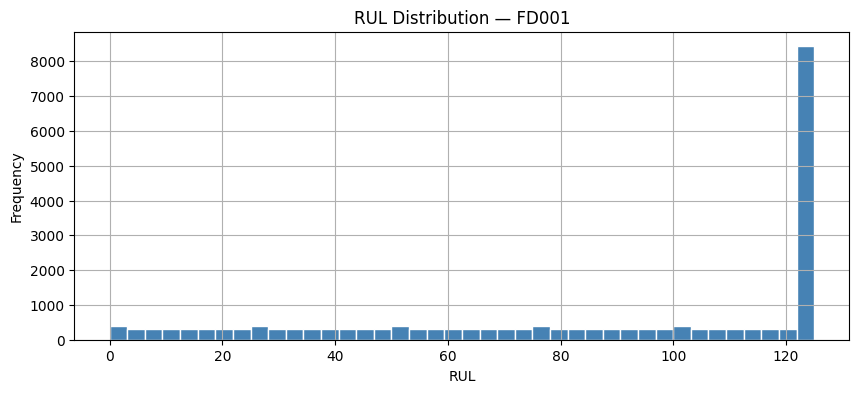

  Xs_train:(13361, 40, 22)  Xs_val:(3270, 40, 22)  Xs_test:(100, 40, 22)
  Xo_train:(13361, 40, 3)  Xo_val:(3270, 40, 3)  Xo_test:(100, 40, 3)

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


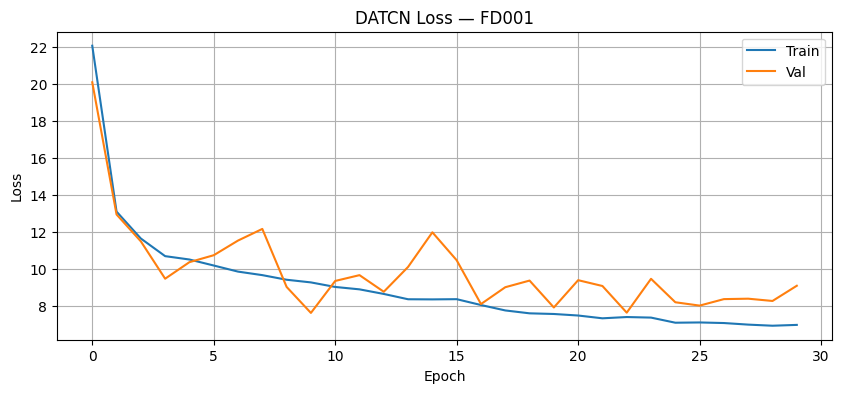


  Val  ↓
  DATCN                                    RMSE=11.415  MAE=8.104  NASA=6954.5
  Test ↓
  DATCN                                    RMSE=17.679  MAE=12.524  NASA=667.9


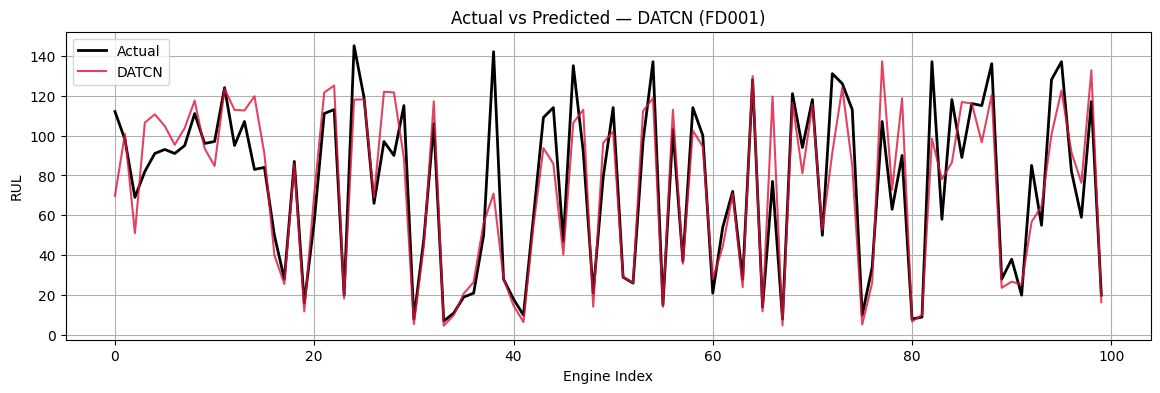

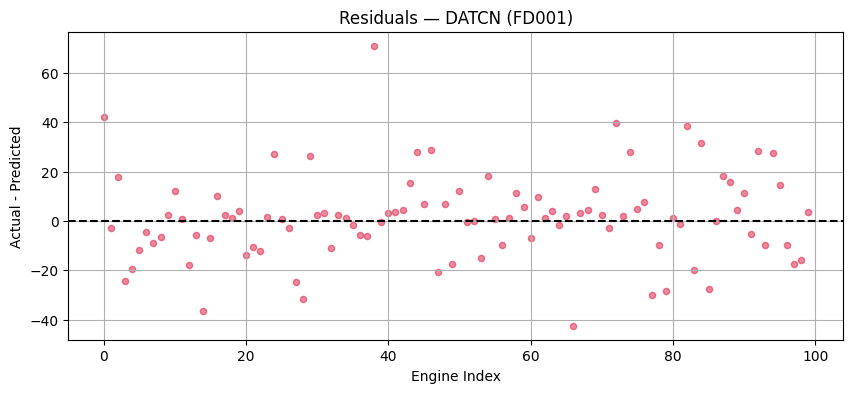


───────────────────────────────────────────────────────
  FD002
───────────────────────────────────────────────────────


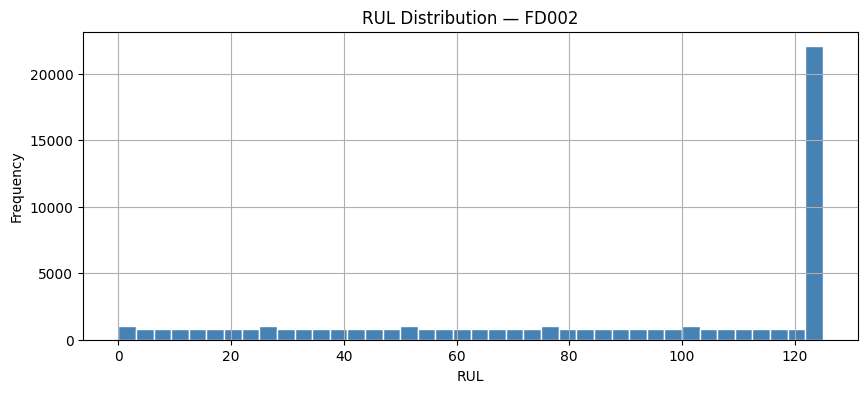

  Xs_train:(35144, 40, 22)  Xs_val:(8215, 40, 22)  Xs_test:(259, 40, 22)
  Xo_train:(35144, 40, 3)  Xo_val:(8215, 40, 3)  Xo_test:(259, 40, 3)

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


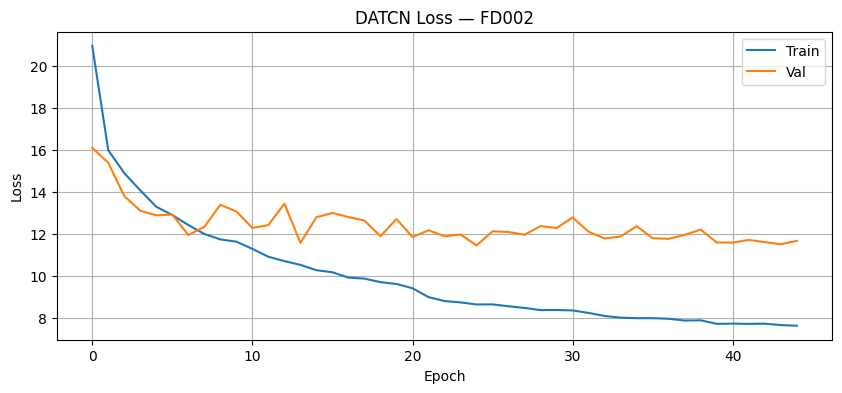


  Val  ↓
  DATCN                                    RMSE=17.281  MAE=11.929  NASA=97302.5
  Test ↓
  DATCN                                    RMSE=30.022  MAE=19.572  NASA=152208.7


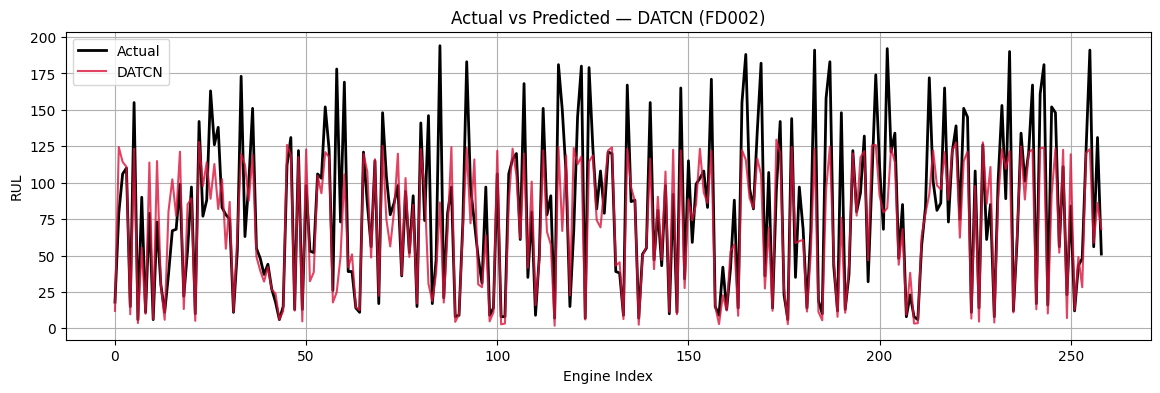

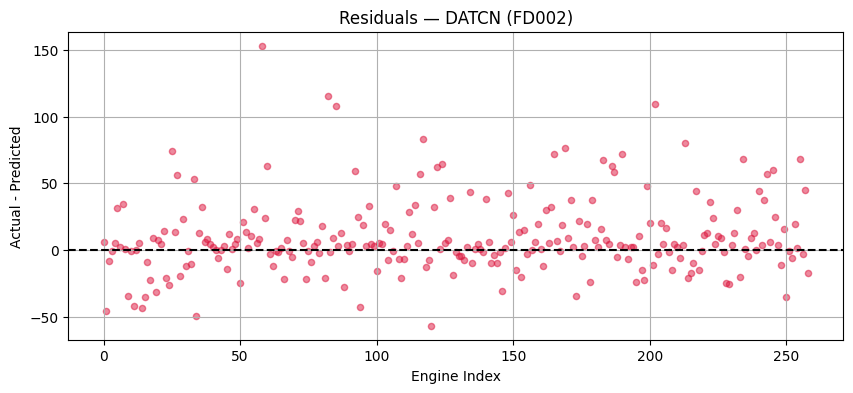


───────────────────────────────────────────────────────
  FD003
───────────────────────────────────────────────────────


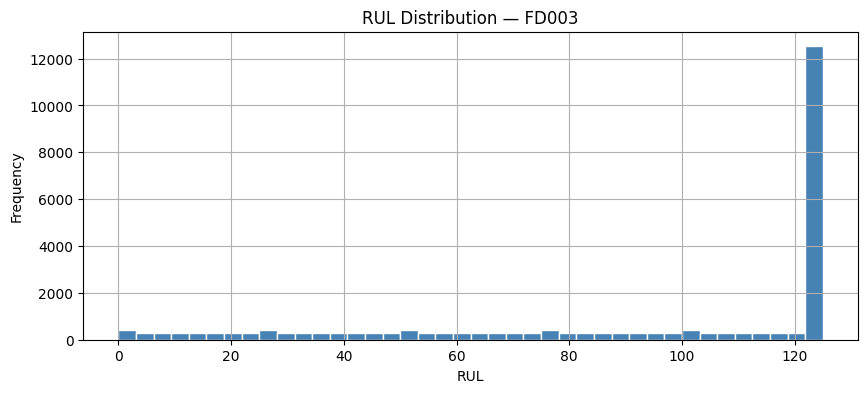

  Xs_train:(16812, 40, 22)  Xs_val:(3908, 40, 22)  Xs_test:(100, 40, 22)
  Xo_train:(16812, 40, 3)  Xo_val:(3908, 40, 3)  Xo_test:(100, 40, 3)

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


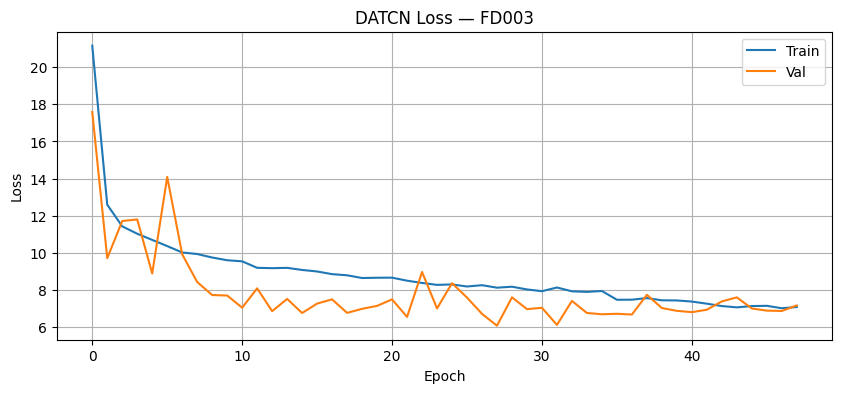


  Val  ↓
  DATCN                                    RMSE=10.557  MAE=6.537  NASA=8565.4
  Test ↓
  DATCN                                    RMSE=15.196  MAE=11.137  NASA=437.4


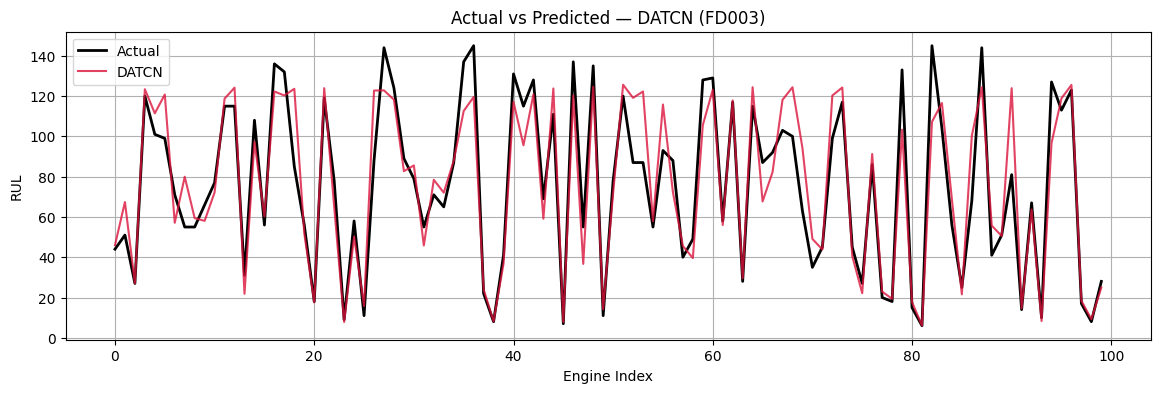

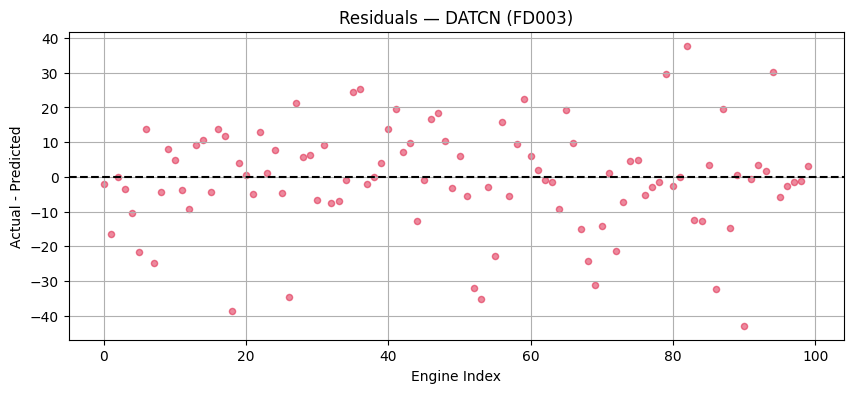


───────────────────────────────────────────────────────
  FD004
───────────────────────────────────────────────────────


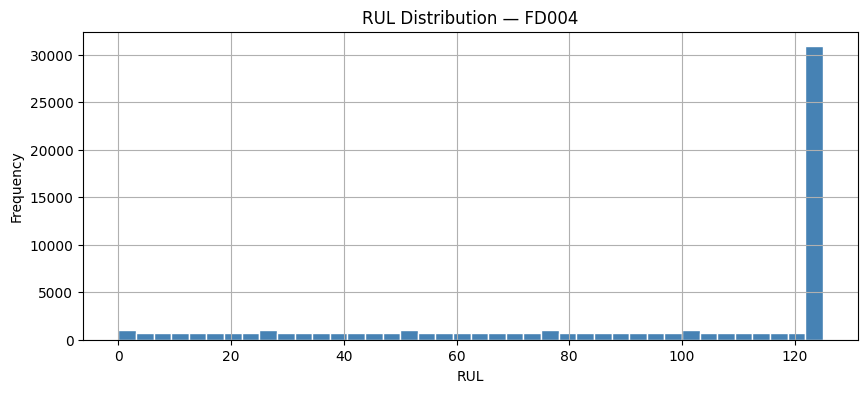

  Xs_train:(41334, 40, 22)  Xs_val:(9955, 40, 22)  Xs_test:(248, 40, 22)
  Xo_train:(41334, 40, 3)  Xo_val:(9955, 40, 3)  Xo_test:(248, 40, 3)

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 45: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


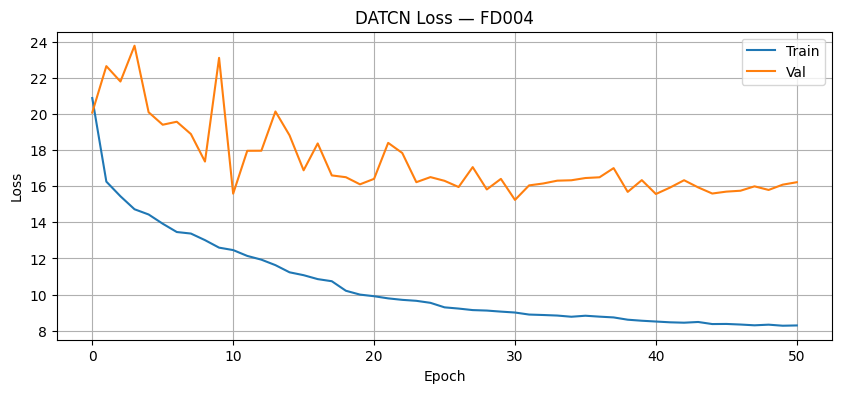


  Val  ↓
  DATCN                                    RMSE=23.147  MAE=15.728  NASA=207422.8
  Test ↓
  DATCN                                    RMSE=30.452  MAE=21.724  NASA=15240.1


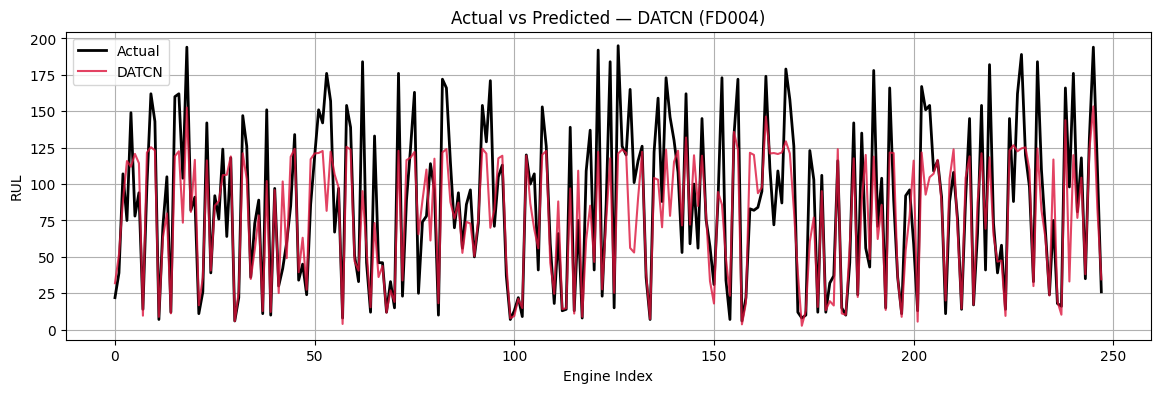

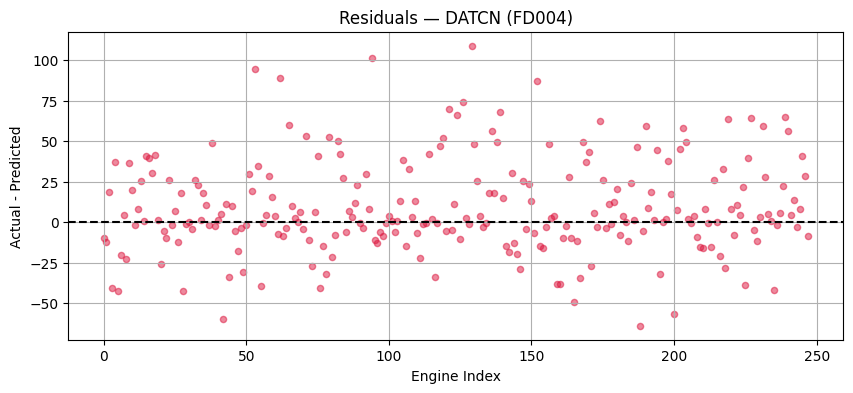


═════════════════════════════════════════════════════════════════
  DATCN BASELINE RESULTS
═════════════════════════════════════════════════════════════════
  Dataset        RMSE      MAE        MSE       NASA
  ────────── ──────── ──────── ────────── ──────────
  FD001        17.679   12.524    312.539      667.9
  FD002        30.022   19.572    901.299   152208.7
  FD003        15.196   11.137    230.933      437.4
  FD004        30.452   21.724    927.309    15240.1

  Average RMSE : 23.337


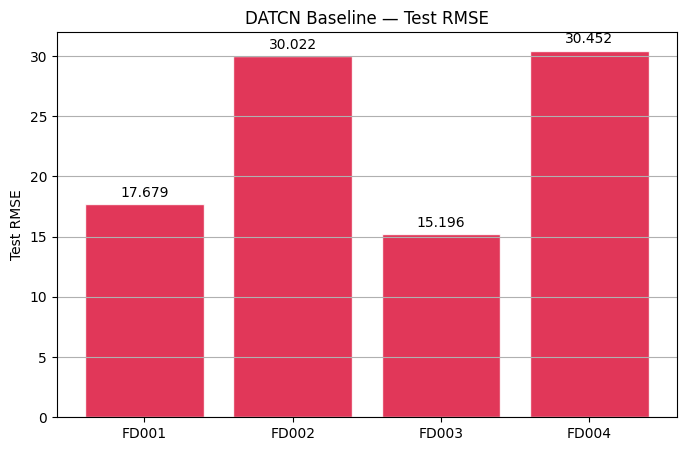


  Predictions saved in all_results[dataset]['test_preds']


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# DATCN — SNIPPET 2: TRAINING + EVALUATION + BASELINE (PHASE 0)
# Unchanged.
# ══════════════════════════════════════════════════════════════════════════════

def compute_mmd_loss(source_feat, target_feat, kernel_scales=[0.5, 1.0, 2.0]):
    def rbf(x, y, sigma):
        dist = tf.reduce_sum(
            tf.square(tf.expand_dims(x, 1) - tf.expand_dims(y, 0)), axis=-1)
        return tf.exp(-dist / (2.0 * sigma**2))
    mmd = 0.0
    for sigma in kernel_scales:
        k_ss = rbf(source_feat, source_feat, sigma)
        k_tt = rbf(target_feat, target_feat, sigma)
        k_st = rbf(source_feat, target_feat, sigma)
        mmd += (tf.reduce_mean(k_ss) - 2.0*tf.reduce_mean(k_st) + tf.reduce_mean(k_tt))
    return mmd / len(kernel_scales)

def train_with_mmd(model, Xs_tr, Xo_tr, y_tr, Xs_val, Xo_val, y_val,
                   Xs_tgt, Xo_tgt, hp):
    feat_model = Model(inputs=model.inputs, outputs=model.get_layer('fusion').output)
    optimizer  = Adam(hp['lr'], clipnorm=1.0)
    huber      = Huber()
    bs         = hp['batch_size']
    n_src      = len(y_tr); n_tgt = len(Xs_tgt)
    best_val   = np.inf; best_w = None; no_imp = 0

    print(f"  [MK-MMD] α={hp['alpha']} | source={n_src} | target={n_tgt}")
    for epoch in range(hp['epochs']):
        idx = np.random.permutation(n_src)
        Xs_tr = Xs_tr[idx]; Xo_tr = Xo_tr[idx]; y_tr = y_tr[idx]
        e_losses = []
        for s in range(0, n_src, bs):
            e = min(s+bs, n_src)
            Xs_b = Xs_tr[s:e]; Xo_b = Xo_tr[s:e]; y_b = y_tr[s:e]
            ti   = np.random.choice(n_tgt, size=len(y_b), replace=True)
            Xs_tb= Xs_tgt[ti]; Xo_tb = Xo_tgt[ti]
            with tf.GradientTape() as tape:
                pred     = model([Xs_b, Xo_b], training=True)
                reg_loss = huber(y_b, pred)
                sf = feat_model([Xs_b,  Xo_b],  training=True)
                tf_ = feat_model([Xs_tb, Xo_tb], training=True)
                mmd_loss   = compute_mmd_loss(sf, tf_)
                total_loss = reg_loss + hp['alpha'] * mmd_loss
            grads = tape.gradient(total_loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            e_losses.append(float(total_loss))

        vp       = model([Xs_val, Xo_val], training=False).numpy().flatten()
        val_rmse = np.sqrt(mean_squared_error(y_val, vp))
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Loss={np.mean(e_losses):.4f} | Val RMSE={val_rmse:.3f}")
        if val_rmse < best_val:
            best_val = val_rmse; best_w = model.get_weights(); no_imp = 0
        else:
            no_imp += 1
        if no_imp >= hp['patience_es']:
            print(f"  Early stop at epoch {epoch+1}")
            break

    if best_w: model.set_weights(best_w)
    return model

# ── Callbacks ────────────────────────────────────────────────────────────────
def get_callbacks(hp):
    return [
        EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=hp['lr_factor'],
                          patience=hp['patience_lr'], min_lr=hp['min_lr'], verbose=1)
    ]

# ── Train + evaluate (full pipeline) ──────────────────────────────────────────
def train_and_evaluate(dataset, hp, show_plots=True):
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    train_raw, test_raw, y_test = load_data(dataset)
    train_df, test_df           = preprocess(train_raw.copy(), test_raw.copy(), dataset)
    if show_plots: plot_rul_dist(train_df, dataset)

    eids             = train_df['id'].unique()
    tr_e, val_e      = train_test_split(eids, test_size=0.2, random_state=SEED)
    Xs_tr, Xo_tr, y_tr   = create_sequences(train_df[train_df['id'].isin(tr_e)], SEQ_LEN)
    Xs_val, Xo_val, y_val = create_sequences(train_df[train_df['id'].isin(val_e)], SEQ_LEN)
    Xs_te, Xo_te          = create_test_sequences(test_df, SEQ_LEN)

    print(f"  Xs_train:{Xs_tr.shape}  Xs_val:{Xs_val.shape}  Xs_test:{Xs_te.shape}")
    print(f"  Xo_train:{Xo_tr.shape}  Xo_val:{Xo_val.shape}  Xo_test:{Xo_te.shape}")

    model = build_datcn(SEQ_LEN, N_SENSOR, N_OP, hp)

    if hp.get('use_mmd', False):
        model = train_with_mmd(model, Xs_tr, Xo_tr, y_tr, Xs_val, Xo_val, y_val,
                                Xs_te, Xo_te, hp)
        hist = None
    else:
        hist = model.fit([Xs_tr, Xo_tr], y_tr,
                          validation_data=([Xs_val, Xo_val], y_val),
                          epochs=hp['epochs'], batch_size=hp['batch_size'],
                          callbacks=get_callbacks(hp), verbose=0)
        if show_plots and hist: plot_loss(hist, dataset)

    vp = model.predict([Xs_val, Xo_val], verbose=0).flatten()
    tp = model.predict([Xs_te,  Xo_te],  verbose=0).flatten()

    assert vp.shape == y_val.shape,  f"Val mismatch: {vp.shape} vs {y_val.shape}"
    assert tp.shape == y_test.shape, f"Test mismatch: {tp.shape} vs {y_test.shape}"

    print(f"\n  Val  ↓"); report_metrics('DATCN', y_val, vp)
    print(f"  Test ↓"); r, m, ms, n = report_metrics('DATCN', y_test, tp)

    if show_plots:
        plot_predictions(y_test, tp, dataset)
        plot_residuals(y_test, tp, dataset)

    return {'rmse':r, 'mae':m, 'mse':ms, 'nasa':n,
            'val_preds':vp, 'test_preds':tp, 'y_val':y_val, 'y_test':y_test}

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 0: BASELINE — paper default HP, all 4 datasets
# ══════════════════════════════════════════════════════════════════════════════
DATASETS    = ['FD001','FD002','FD003','FD004']
all_results = {}

print(f"\n{'█'*60}")
print(f"  DATCN BASELINE — Paper Default HP")
print(f"  use_mmd={HP_DEFAULT['use_mmd']} | n_blocks={HP_DEFAULT['n_tcn_blocks']} | "
      f"lr={HP_DEFAULT['lr']} | seq={SEQ_LEN}")
print(f"{'█'*60}")

for dataset in DATASETS:
    print(f"\n{'─'*55}\n  {dataset}\n{'─'*55}")
    result               = train_and_evaluate(dataset, HP_DEFAULT)
    all_results[dataset] = result

print(f"\n{'═'*65}")
print(f"  DATCN BASELINE RESULTS")
print(f"{'═'*65}")
print(f"  {'Dataset':<10} {'RMSE':>8} {'MAE':>8} {'MSE':>10} {'NASA':>10}")
print(f"  {'':─<10} {'':─>8} {'':─>8} {'':─>10} {'':─>10}")
for ds in DATASETS:
    r = all_results[ds]
    print(f"  {ds:<10} {r['rmse']:>8.3f} {r['mae']:>8.3f} {r['mse']:>10.3f} {r['nasa']:>10.1f}")

avg = np.mean([all_results[ds]['rmse'] for ds in DATASETS])
print(f"\n  Average RMSE : {avg:.3f}")
plot_rmse_bar(all_results, 'DATCN Baseline — Test RMSE')
print(f"\n  Predictions saved in all_results[dataset]['test_preds']")

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# DATCN — SNIPPET 3: SUBPROCESS WORKER + MEMORY-SAFE SEARCH HELPERS
# FIX (Keras 3): WORKER_CODE's GlobalAttentionBlock now uses keras.ops, matching
# Snippet 1 — this is what was causing every trial to return inf.
# NEW: smoke_test_worker() — runs ONE real subprocess trial and, on failure,
# prints the FULL stderr (not the truncated [-200:] tail) so the actual
# exception is visible immediately.
# ══════════════════════════════════════════════════════════════════════════════
import gc, optuna, subprocess, json, sys, os, ctypes
optuna.logging.set_verbosity(optuna.logging.WARNING)

WORKER_PATH  = '/tmp/datcn_worker.py'
ARRAY_PREFIX = '/tmp/datcn_arrays'

def _trim_ram():
    try: ctypes.cdll.LoadLibrary("libc.so.6").malloc_trim(0)
    except Exception: pass

# ── Worker script — runs in its own process, dies after one trial ─────────────
WORKER_CODE = r"""
import os, sys, json, numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS']       = 'ignore'
import warnings; warnings.filterwarnings('ignore')

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    except: pass

from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Layer, Activation,
    BatchNormalization, GlobalAveragePooling1D, Concatenate)
from tensorflow.keras import ops as kops
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

def tcn_block(x, filters, kernel_size, dilation_rate, dropout, prefix='tcn'):
    res = x
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, name=f'{prefix}_c1')(x)
    x = BatchNormalization(name=f'{prefix}_bn1')(x)
    x = Activation('relu')(x); x = Dropout(dropout)(x)
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, name=f'{prefix}_c2')(x)
    x = BatchNormalization(name=f'{prefix}_bn2')(x)
    x = Activation('relu')(x); x = Dropout(dropout)(x)
    if res.shape[-1] != filters:
        res = Conv1D(filters, 1, name=f'{prefix}_res_proj')(res)
    return Add(name=f'{prefix}_add')([x, res])

def op_cnn_block(x, filters, kernel_size, dropout, prefix='op_cnn'):
    x = Conv1D(filters, kernel_size, padding='same',
               activation='relu', name=f'{prefix}_c1')(x)
    x = BatchNormalization(name=f'{prefix}_bn1')(x); x = Dropout(dropout)(x)
    x = Conv1D(filters, kernel_size, padding='same',
               activation='relu', name=f'{prefix}_c2')(x)
    x = BatchNormalization(name=f'{prefix}_bn2')(x); x = Dropout(dropout)(x)
    return x

class GlobalAttentionBlock(Layer):
    def __init__(self, d_attn, use_residual=False, **kwargs):
        super().__init__(**kwargs)
        self.d_attn       = d_attn
        self.use_residual = use_residual
        self.scale        = d_attn ** -0.5
        self.q_pool   = GlobalAveragePooling1D()
        self.q_proj   = Dense(d_attn)
        self.k_proj   = Dense(d_attn)
        self.v_proj   = Dense(d_attn)
        self.enc_pool = GlobalAveragePooling1D()
        self.enc_proj = Dense(d_attn)
        self.out_proj = Dense(d_attn, activation='tanh')
        self.concat   = Concatenate()
        self.add      = Add() if use_residual else None

    def call(self, inputs):
        raw_in, encoded = inputs
        q = self.q_proj(self.q_pool(raw_in))
        q = kops.expand_dims(q, axis=1)
        k = self.k_proj(encoded)
        v = self.v_proj(encoded)
        k_t     = kops.transpose(k, axes=(0, 2, 1))
        scores  = kops.matmul(q, k_t) * self.scale
        weights = kops.softmax(scores, axis=-1)
        context = kops.squeeze(kops.matmul(weights, v), axis=1)
        enc_p   = self.enc_proj(self.enc_pool(encoded))
        out     = self.out_proj(self.concat([context, enc_p]))
        if self.use_residual:
            out = self.add([out, enc_p])
        return out

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'d_attn': self.d_attn, 'use_residual': self.use_residual})
        return cfg

def build_datcn(seq_len, n_sensor, n_op, hp):
    F, Fo, D, dr = hp['tcn_filters'], hp['cnn_filters'], hp['d_attn'], hp['dropout']
    sensor_in = Input(shape=(seq_len, n_sensor), name='sensor_input')
    op_in     = Input(shape=(seq_len, n_op),     name='op_input')

    xs = Conv1D(F, 1, padding='same', name='sensor_proj')(sensor_in)
    for i in range(hp['n_tcn_blocks']):
        xs = tcn_block(xs, F, hp['tcn_kernel'], dilation_rate=2**i,
                       dropout=dr, prefix=f'tcn_{i}')

    xo = op_cnn_block(op_in, Fo, hp['cnn_kernel'], dr)

    a_s = GlobalAttentionBlock(D, use_residual=True,  name='attn_B_sensor')([sensor_in, xs])
    a_o = GlobalAttentionBlock(D, use_residual=False, name='attn_A_op')([op_in, xo])

    fused  = Concatenate(name='fusion')([a_s, a_o])
    x      = Dense(hp['fc_units'], activation='relu', name='fc1')(fused)
    x      = Dropout(dr)(x)
    output = Dense(1, name='output')(x)

    m = Model(inputs=[sensor_in, op_in], outputs=output, name='DATCN')
    m.compile(optimizer=Adam(hp['lr'], clipnorm=1.0), loss=Huber(), metrics=['mae'])
    return m

hp     = json.loads(sys.argv[1])
prefix = sys.argv[2]
SEQ    = int(sys.argv[3])

Xs_tr  = np.load(f'{prefix}_Xs_tr.npy')
Xo_tr  = np.load(f'{prefix}_Xo_tr.npy')
ytr    = np.load(f'{prefix}_ytr.npy')
Xs_val = np.load(f'{prefix}_Xs_val.npy')
Xo_val = np.load(f'{prefix}_Xo_val.npy')
yval   = np.load(f'{prefix}_yval.npy')

cbs = [EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                     restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=hp.get('patience_lr', 5), min_lr=1e-7)]
try:
    m = build_datcn(SEQ, Xs_tr.shape[2], Xo_tr.shape[2], hp)
    m.fit([Xs_tr, Xo_tr], ytr, validation_data=([Xs_val, Xo_val], yval),
          epochs=hp['epochs'], batch_size=hp['batch_size'],
          callbacks=cbs, verbose=0)
    for cb in cbs:
        if hasattr(cb, 'best_weights'): cb.best_weights = None
    vp = m.predict([Xs_val, Xo_val], verbose=0).flatten()
    print(float(np.sqrt(mean_squared_error(yval, vp))))
    sys.exit(0)
except Exception:
    import traceback; traceback.print_exc(file=sys.stderr)
    sys.exit(1)
"""

# ── Write worker to disk ───────────────────────────────────────────────────────
def write_worker():
    with open(WORKER_PATH, 'w') as f:
        f.write(WORKER_CODE)
    print(f"  Worker written → {WORKER_PATH}")

# ── Run one trial in a fresh subprocess ────────────────────────────────────────
def run_isolated(hp, timeout=420):
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH, json.dumps(hp), ARRAY_PREFIX, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
        if r.returncode == 0 and r.stdout.strip():
            return float(r.stdout.strip())
        if r.stderr:
            print(f"    [err] {r.stderr.strip()[-200:]}")
        return float('inf')
    except subprocess.TimeoutExpired:
        print(f"    [timeout {timeout}s]")
        return float('inf')
    except Exception as e:
        print(f"    [exc] {e}")
        return float('inf')

# ── NEW: fail-fast smoke test — ONE real subprocess trial, full stderr on fail ─
def smoke_test_worker(epochs_search=2, timeout=180):
    test_hp = {
        'n_tcn_blocks': 2, 'tcn_filters': 32, 'tcn_kernel': 2,
        'cnn_filters': 16, 'cnn_kernel': 1, 'd_attn': 32, 'fc_units': 32,
        'dropout': 0.1, 'lr': 1e-3, 'batch_size': 64,
        'epochs': epochs_search, 'patience_es': 5, 'patience_lr': 3,
    }
    print(f"\n  ── Smoke test: 1 subprocess trial ({epochs_search} epochs) ──")
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH, json.dumps(test_hp), ARRAY_PREFIX, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        print(f"  Smoke test TIMED OUT after {timeout}s")
        return False

    if r.returncode == 0 and r.stdout.strip():
        print(f"  Smoke test OK — val RMSE: {float(r.stdout.strip()):.3f}")
        return True

    print(f"  Smoke test FAILED — full worker stderr:\n{r.stderr}")
    return False

# ── Save precomputed two-channel arrays to disk, free from parent RAM ─────────
def save_arrays(Xs_tr, Xo_tr, ytr, Xs_val, Xo_val, yval):
    np.save(f'{ARRAY_PREFIX}_Xs_tr.npy',  Xs_tr)
    np.save(f'{ARRAY_PREFIX}_Xo_tr.npy',  Xo_tr)
    np.save(f'{ARRAY_PREFIX}_ytr.npy',    ytr)
    np.save(f'{ARRAY_PREFIX}_Xs_val.npy', Xs_val)
    np.save(f'{ARRAY_PREFIX}_Xo_val.npy', Xo_val)
    np.save(f'{ARRAY_PREFIX}_yval.npy',   yval)
    mb = (Xs_tr.nbytes + Xo_tr.nbytes + Xs_val.nbytes + Xo_val.nbytes) / 1e6
    print(f"  Arrays saved to {ARRAY_PREFIX}_*.npy  ({mb:.0f} MB on disk)")

# ── Warm-start Bayesian Phase 2 from top-N Random Search trials ──────────────
def _run_phase2(rs, n_bayes, top_n, objective_fn):
    sorted_t    = sorted(rs.trials, key=lambda t: t.value)
    seeds       = [(t.params, t.distributions, t.value) for t in sorted_t[:top_n]]
    p1_best     = sorted_t[0].value
    del sorted_t; gc.collect()

    bs = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=top_n))

    for p, d, v in seeds:
        bs.add_trial(optuna.trial.create_trial(params=p, distributions=d, value=v))
    del seeds; gc.collect()

    print(f"  {top_n} seeds transferred (0 GPU). Running {n_bayes} new Bayesian trials...")

    def _cb(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        print(f"    Trial {trial.number+1:3d}: "
              f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")
        gc.collect(); _trim_ram()

    bs.optimize(objective_fn, n_trials=n_bayes, callbacks=[_cb])

    best = bs.best_trial
    print(f"\n  Phase1 best={p1_best:.3f}  Phase2 best={best.value:.3f}  "
          f"Δ={p1_best-best.value:+.3f}")

    try:
        imp = optuna.importance.get_param_importances(bs)
        plt.figure(figsize=(10, 4))
        plt.barh(list(imp.keys()), list(imp.values()), color='crimson')
        plt.title('HP Importance — DATCN (Subprocess Bayesian)')
        plt.tight_layout(); plt.grid(axis='x'); plt.show()
    except Exception:
        pass
    return bs

print("DATCN subprocess worker + search helpers loaded.")

DATCN subprocess worker + search helpers loaded.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# DATCN — SNIPPET 4: COMBINED RANDOM + WARM-STARTED BAYESIAN SEARCH
# MODIFIED: smoke_test_worker() runs right after save_arrays. If it fails,
# the search aborts with the full traceback instead of running 40 inf trials.
# ══════════════════════════════════════════════════════════════════════════════
def datcn_combined_search(n_random=20, n_bayes=20, top_n=5,
                           dataset='FD001', epochs_search=40):
    print(f"\n{'═'*65}")
    print(f"  DATCN COMBINED SEARCH  |  {dataset}")
    print(f"  Phase1: Random {n_random}  |  Phase2: Bayesian {n_bayes} new trials "
          f"(seeded with top {top_n})")
    print(f"  Each trial = fresh subprocess → TF RAM fully reclaimed after exit")
    print(f"  Total subprocess evaluations: {n_random + n_bayes}")
    print(f"{'═'*65}")

    write_worker()

    tr, _, _    = load_data(dataset)
    train_df, _ = preprocess(tr.copy(), tr.copy(), dataset)
    del tr
    eids        = train_df['id'].unique()
    tr_e, val_e = train_test_split(eids, test_size=0.2, random_state=SEED)
    Xs_tr,  Xo_tr,  ytr  = create_sequences(train_df[train_df['id'].isin(tr_e)],  SEQ_LEN)
    Xs_val, Xo_val, yval = create_sequences(train_df[train_df['id'].isin(val_e)], SEQ_LEN)
    del train_df
    save_arrays(Xs_tr, Xo_tr, ytr, Xs_val, Xo_val, yval)
    del Xs_tr, Xo_tr, ytr, Xs_val, Xo_val, yval
    gc.collect(); _trim_ram()

    # MODIFIED: fail-fast gate before launching the full search
    if not smoke_test_worker(epochs_search=2):
        print("\n  ABORTING — fix build_datcn / WORKER_CODE using the traceback above.")
        print("  Re-run Snippet 1 (confirm the forward+backward smoke test passes),")
        print("  then re-run Snippet 3, then retry Snippet 5.")
        return None, None, None

    def objective(trial):
        hp = {
            'n_tcn_blocks': trial.suggest_int('n_tcn_blocks', 2, 6),
            'tcn_filters' : trial.suggest_categorical('tcn_filters', [32, 64, 128]),
            'tcn_kernel'  : trial.suggest_categorical('tcn_kernel', [2, 3]),
            'cnn_filters' : trial.suggest_categorical('cnn_filters', [16, 32, 64]),
            'cnn_kernel'  : trial.suggest_categorical('cnn_kernel', [1, 2, 3]),
            'd_attn'      : trial.suggest_categorical('d_attn', [32, 64, 128]),
            'fc_units'    : trial.suggest_categorical('fc_units', [32, 64, 128]),
            'dropout'     : trial.suggest_float('dropout', 0.10, 0.40),
            'lr'          : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size'  : trial.suggest_categorical('batch_size', [32, 64, 128]),
            'epochs'      : epochs_search,
            'patience_es' : 10,
            'patience_lr' : 4,
        }
        return run_isolated(hp)

    print(f"\n  ── Phase 1: Random Search ({n_random} trials) ──")
    rs = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.RandomSampler(seed=SEED))

    def _cb1(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        print(f"    Trial {trial.number+1:3d}: "
              f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")
        gc.collect(); _trim_ram()

    rs.optimize(objective, n_trials=n_random, callbacks=[_cb1])

    print(f"\n  Top {top_n} from Phase 1:")
    sorted_show = sorted(rs.trials, key=lambda t: t.value)
    for i, t in enumerate(sorted_show[:top_n]):
        p = t.params
        print(f"    #{i+1}  RMSE={t.value:.3f}  blocks={p['n_tcn_blocks']}  "
              f"filt={p['tcn_filters']}  d_attn={p['d_attn']}  lr={p['lr']:.1e}")
    del sorted_show

    print(f"\n  ── Phase 2: Bayesian ({n_bayes} new trials, seeded from Phase 1) ──")
    bs = _run_phase2(rs, n_bayes, top_n, objective)

    p = bs.best_trial.params
    best_hp = {
        'n_tcn_blocks': p['n_tcn_blocks'],
        'tcn_filters' : p['tcn_filters'],
        'tcn_kernel'  : p['tcn_kernel'],
        'cnn_filters' : p['cnn_filters'],
        'cnn_kernel'  : p['cnn_kernel'],
        'd_attn'      : p['d_attn'],
        'fc_units'    : p['fc_units'],
        'dropout'     : p['dropout'],
        'lr'          : p['lr'],
        'batch_size'  : p['batch_size'],
        'epochs'      : 100,
        'patience_es' : 25,
        'patience_lr' : 6,
        'lr_factor'   : 0.5,
        'min_lr'      : 1e-7,
        'use_mmd'     : False,
        'alpha'       : 1e-6,
    }
    print(f"\n  Best HP: {best_hp}")
    return best_hp, rs, bs

print("DATCN combined search function loaded. Run Snippet 5 to start search.")

DATCN combined search function loaded. Run Snippet 5 to start search.



═════════════════════════════════════════════════════════════════
  DATCN COMBINED SEARCH  |  FD001
  Phase1: Random 20  |  Phase2: Bayesian 20 new trials (seeded with top 5)
  Each trial = fresh subprocess → TF RAM fully reclaimed after exit
  Total subprocess evaluations: 40
═════════════════════════════════════════════════════════════════
  Worker written → /tmp/datcn_worker.py
  Arrays saved to /tmp/datcn_arrays_*.npy  (67 MB on disk)

  ── Smoke test: 1 subprocess trial (2 epochs) ──
  Smoke test OK — val RMSE: 20.057

  ── Phase 1: Random Search (20 trials) ──
    Trial   1: 12.651 ← BEST
    Trial   2: 14.183 
    Trial   3: 12.460 ← BEST
    Trial   4: 12.375 ← BEST
    Trial   5: 12.573 
    Trial   6: 12.027 ← BEST
    Trial   7: 11.990 ← BEST
    Trial   8: 11.543 ← BEST
    Trial   9: 14.432 
    Trial  10: 11.474 ← BEST
    Trial  11: 12.463 
    Trial  12: 14.356 
    Trial  13: 12.637 
    Trial  14: 13.848 
    Trial  15: 13.352 
    Trial  16: 11.374 ← BEST
    Trial 

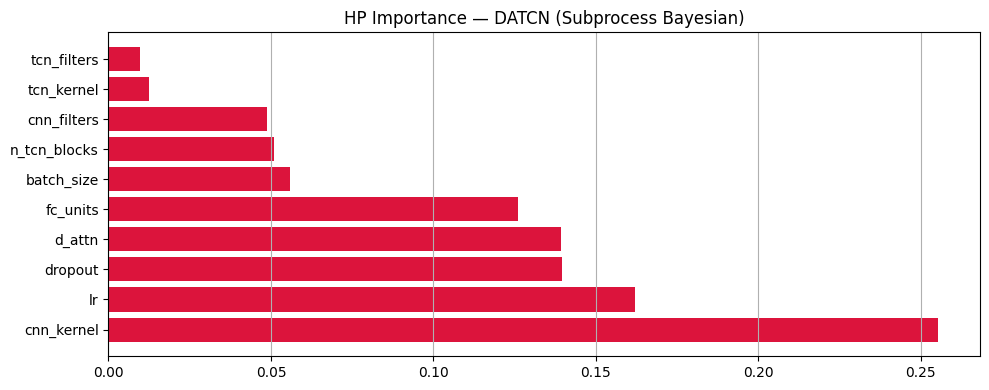


  Best HP: {'n_tcn_blocks': 4, 'tcn_filters': 64, 'tcn_kernel': 3, 'cnn_filters': 32, 'cnn_kernel': 1, 'd_attn': 128, 'fc_units': 32, 'dropout': 0.3342661954789473, 'lr': 0.0016787786545433316, 'batch_size': 32, 'epochs': 100, 'patience_es': 25, 'patience_lr': 6, 'lr_factor': 0.5, 'min_lr': 1e-07, 'use_mmd': False, 'alpha': 1e-06}


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# DATCN — SNIPPET 5: RUN SEARCH
# ══════════════════════════════════════════════════════════════════════════════
best_hp_datcn, rs_datcn, bo_datcn = datcn_combined_search(
    n_random=20, n_bayes=20, top_n=5,
    dataset='FD001', epochs_search=40)


██████████████████████████████████████████████████
  DATCN | FD001
██████████████████████████████████████████████████

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0008393893367610872.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0004196946683805436.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002098473341902718.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001049236670951359.

  Val:
  DATCN                                    RMSE=11.072  MAE=8.366  NASA=5538.8
  Test:
  DATCN                                    RMSE=14.418  MAE=10.390  NASA=308.4


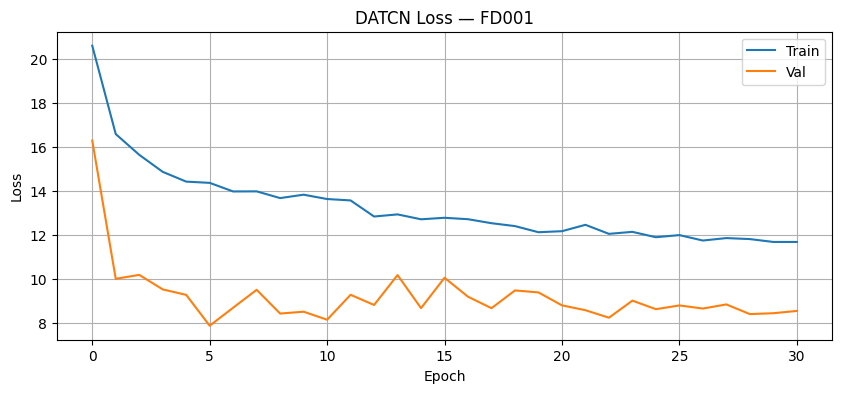

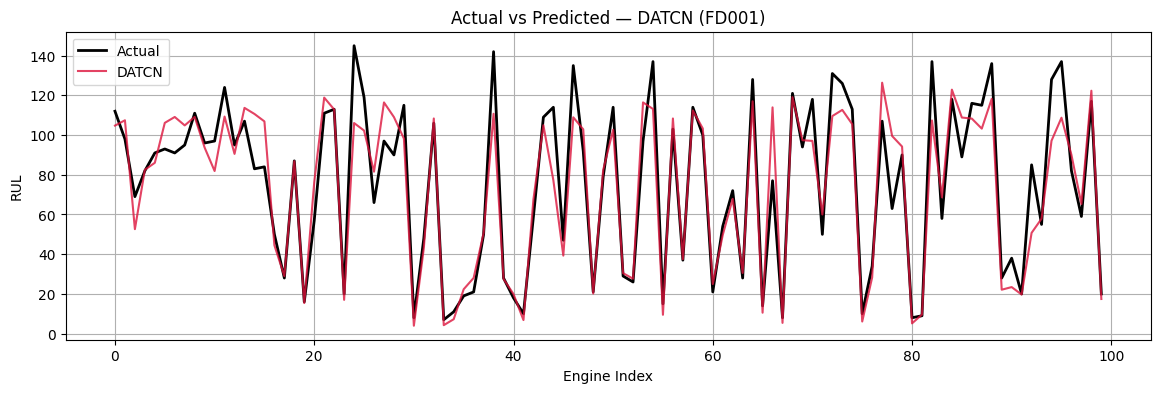


██████████████████████████████████████████████████
  DATCN | FD002
██████████████████████████████████████████████████

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0008393893367610872.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0004196946683805436.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0002098473341902718.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0001049236670951359.

Epoch 47: ReduceLROnPlateau reducing learning rate to 5.246183354756795e-05.

Epoch 56: ReduceLROnPlateau reducing learning rate to 2.6230916773783974e-05.

Epoch 70: ReduceLROnPlateau reducing learning rate to 1.3115458386891987e-05.

Epoch 81: ReduceLROnPlateau reducing learning rate to 6.557729193445994e-06.

Epoch 87: ReduceLROnPlateau reducing learning rate to 3.278864596722997e-06.

Epoch 93: ReduceLROnPlateau reducing learning rate to 1.6394322983614984e-06.

Epoch 99: ReduceLROnPlateau reducing learning rate to 8.197161491807492e-07.

  Val:
  DATCN     

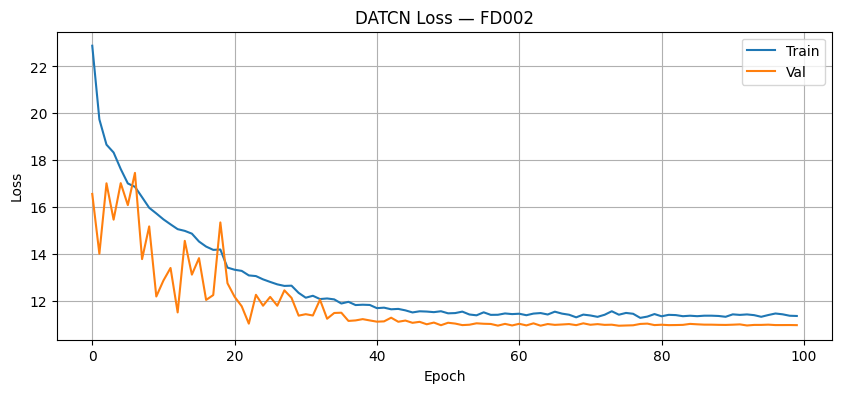

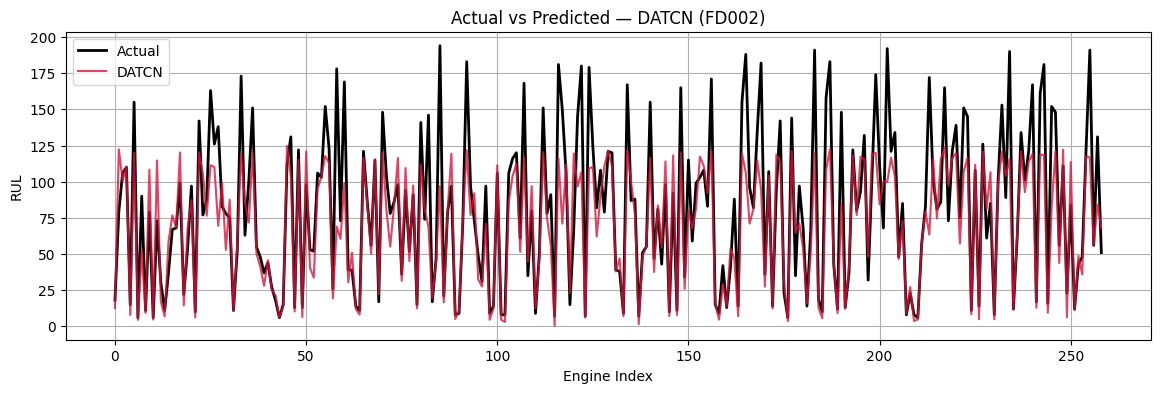


██████████████████████████████████████████████████
  DATCN | FD003
██████████████████████████████████████████████████

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0008393893367610872.

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0004196946683805436.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0002098473341902718.

Epoch 55: ReduceLROnPlateau reducing learning rate to 0.0001049236670951359.

Epoch 61: ReduceLROnPlateau reducing learning rate to 5.246183354756795e-05.

  Val:
  DATCN                                    RMSE=10.899  MAE=6.814  NASA=7366.0
  Test:
  DATCN                                    RMSE=13.760  MAE=9.999  NASA=271.2


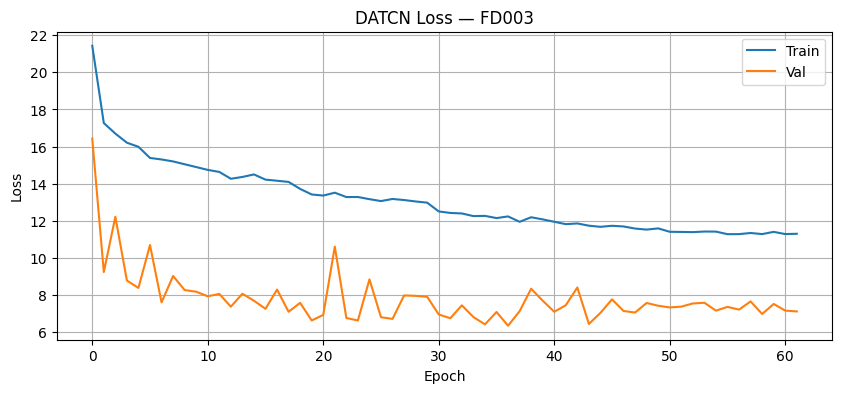

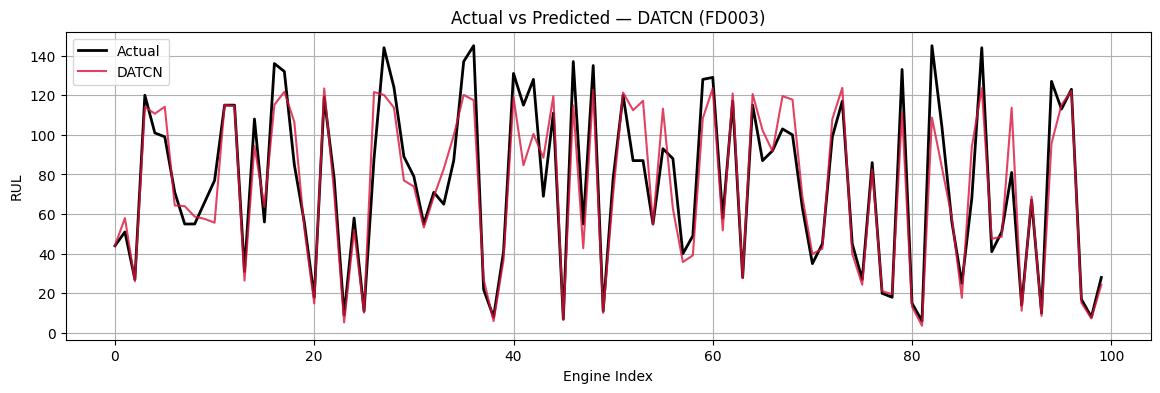


██████████████████████████████████████████████████
  DATCN | FD004
██████████████████████████████████████████████████

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0008393893367610872.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0004196946683805436.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0002098473341902718.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.0001049236670951359.

  Val:
  DATCN                                    RMSE=24.203  MAE=16.089  NASA=236614.8
  Test:
  DATCN                                    RMSE=31.013  MAE=22.214  NASA=13838.1


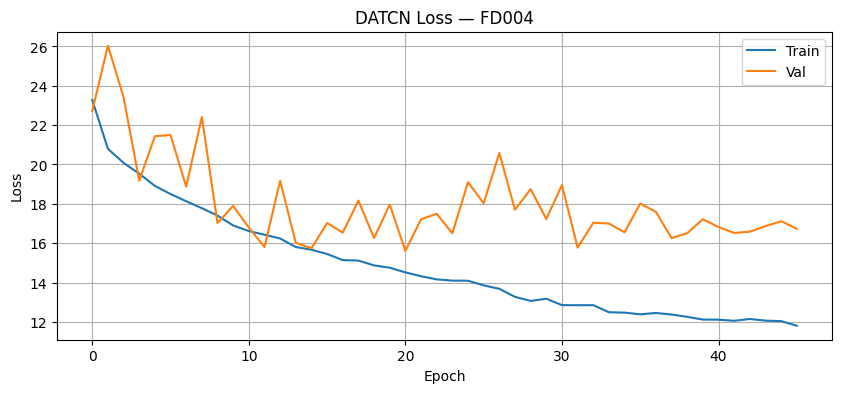

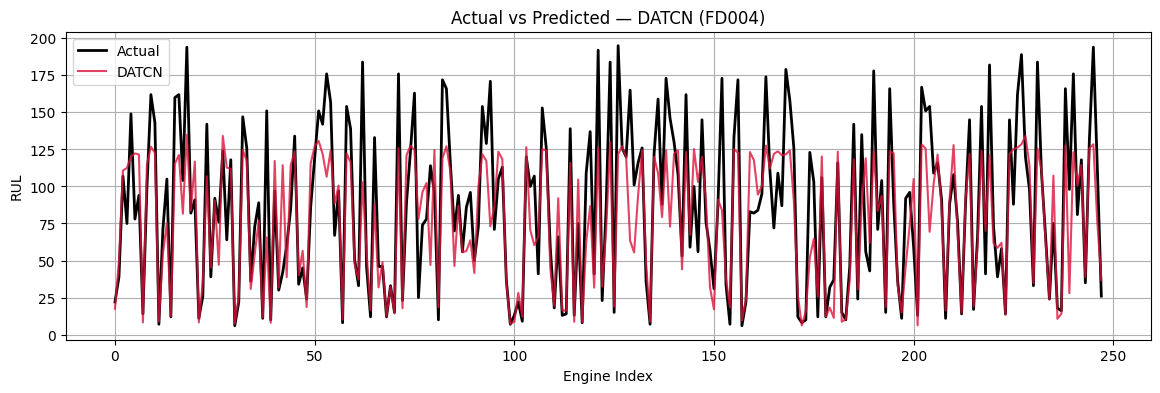


════════════════════════════════════════════════════════════
  DS             RMSE    vs Baseline
  ──────── ────────── ──────────────
  FD001        14.418          -3.261
  FD002        29.090          -0.932
  FD003        13.760          -1.436
  FD004        31.013          +0.561


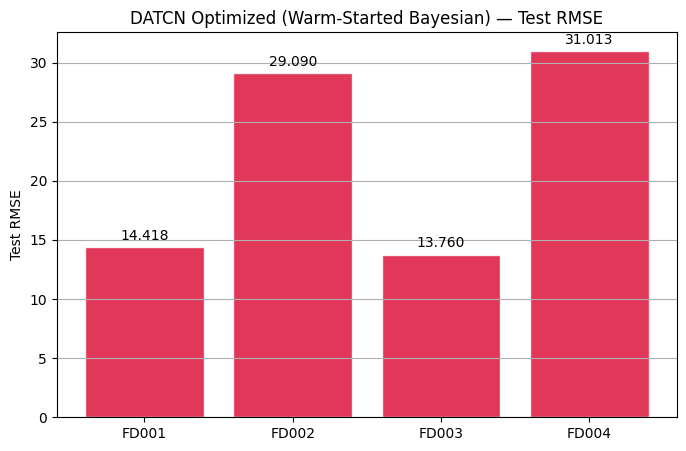

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# DATCN — SNIPPET 6: RETRAIN BEST HP ON ALL 4 DATASETS
# ══════════════════════════════════════════════════════════════════════════════
optimized_datcn = {}

for dataset in DATASETS:
    print(f"\n{'█'*50}\n  DATCN | {dataset}\n{'█'*50}")
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    Xs_tr = Xo_tr = y_train = Xs_val = Xo_val = y_val = Xs_te = Xo_te = model = cbs = None
    try:
        tr, te, y_test = load_data(dataset)
        train_df, test_df = preprocess(tr.copy(), te.copy(), dataset)
        del tr, te

        eids        = train_df['id'].unique()
        tr_e, val_e = train_test_split(eids, test_size=0.2, random_state=SEED)
        Xs_tr,  Xo_tr,  y_train = create_sequences(train_df[train_df['id'].isin(tr_e)],  SEQ_LEN)
        Xs_val, Xo_val, y_val   = create_sequences(train_df[train_df['id'].isin(val_e)], SEQ_LEN)
        Xs_te,  Xo_te           = create_test_sequences(test_df, SEQ_LEN)
        del train_df, test_df

        model = build_datcn(SEQ_LEN, N_SENSOR, N_OP, best_hp_datcn)
        cbs   = get_callbacks(best_hp_datcn)
        hist  = model.fit([Xs_tr, Xo_tr], y_train,
                           validation_data=([Xs_val, Xo_val], y_val),
                           epochs=best_hp_datcn['epochs'],
                           batch_size=best_hp_datcn['batch_size'],
                           callbacks=cbs, verbose=0)

        vp = model.predict([Xs_val, Xo_val], verbose=0).flatten()
        tp = model.predict([Xs_te,  Xo_te],  verbose=0).flatten()

        print("\n  Val:")
        report_metrics("DATCN", y_val, vp)
        print("  Test:")
        r, m, ms, n = report_metrics("DATCN", y_test, tp)
        optimized_datcn[dataset] = {'rmse': r, 'mae': m, 'mse': ms, 'nasa': n, 'test_preds': tp}

        plot_loss(hist, dataset)
        plot_predictions(y_test, tp, dataset)
        del vp, hist

    finally:
        if cbs is not None:
            for cb in cbs:
                if hasattr(cb, 'best_weights'): cb.best_weights = None
        model = cbs = Xs_tr = Xo_tr = y_train = Xs_val = Xo_val = y_val = Xs_te = Xo_te = None
        tf.keras.backend.clear_session()
        gc.collect(); gc.collect()
        _trim_ram()

print(f"\n{'═'*60}")
print(f"  {'DS':<8} {'RMSE':>10} {'vs Baseline':>14}")
print(f"  {'':─<8} {'':─>10} {'':─>14}")
for ds in DATASETS:
    o = optimized_datcn[ds]['rmse']
    b = all_results[ds]['rmse']
    print(f"  {ds:<8} {o:>10.3f}  {o-b:>+14.3f}")

plot_rmse_bar(optimized_datcn, 'DATCN Optimized (Warm-Started Bayesian) — Test RMSE')